# Earnings Announcement — Stock Price Reaction Analysis

**Universe:** Samsung Electronics · SK Hynix · TSMC · Toyota · Alibaba  
**Event Window:** −5 to +10 trading days around each earnings release date  
**Objective:** Quantify and compare abnormal price reactions across recent quarterly earnings

---

## 실적 발표 후 주가 흐름 분석

### 분석 목적
실적 발표는 주가에 강한 단기 충격을 준다.
단순 반응의 크기뿐 아니라 지속성까지 측정하여
실적 발표 후 주가 모멘텀이 언제까지 유지되는지 확인한다.
이는 종목 선별(1번 프로젝트) 이후 **실제 진입 타이밍**을
결정하는 데 활용할 수 있다.

- 분석 대상: SK하이닉스, 삼성전자, TSMC, 도요타, 알리바바
- 분석 기간: 실적 발표일 기준 Day-1 ~ Day+20
- 기준점: Day-1 종가 (발표 당일 반응 포함을 위해 전일 종가 기준)
- 측정 지표: 발표 당일(Day 0) 반응 + 이후 20일간 누적 수익률

## 0. Environment Setup

In [ ]:
# Install required packages (run once)
# !pip install yfinance pandas numpy matplotlib seaborn scipy -q

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats
import warnings
import subprocess
import matplotlib.font_manager as fm

warnings.filterwarnings('ignore')


def setup_font() -> None:
    """Auto-configure a font that supports the runtime environment."""
    # Attempt to install Nanum fonts on Colab / Linux
    try:
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
                       capture_output=True, check=False)
        fm._rebuild()
    except Exception:
        pass

    candidates = ['NanumGothic', 'NanumBarunGothic', 'Malgun Gothic',
                  'AppleGothic', 'DejaVu Sans']
    available = {f.name for f in fm.fontManager.ttflist}
    for font in candidates:
        if font in available:
            plt.rcParams['font.family'] = font
            print(f'Font configured: {font}')
            return
    plt.rcParams['font.family'] = 'sans-serif'
    print('Warning: no preferred font found — using system sans-serif.')


setup_font()
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font_scale=1.1)
print('All libraries loaded successfully.')

Font configured: AppleGothic
All libraries loaded successfully.


## 1. Universe Definition & Earnings Dates

> **Note:** Earnings dates below are manually set for accuracy.  
> Korean-listed tickers (`.KS`) often return no data from `yfinance.earnings_dates` — manual input is recommended.

In [3]:
# ── Universe configuration ────────────────────────────────────────────────────
# Update 'earnings' lists with the actual announcement dates for each quarter.
STOCKS: dict = {
    'Samsung': {
        'ticker'  : '005930.KS',
        'currency': 'KRW',
        'color'   : '#1428A0',
        'earnings': ['2024-01-31', '2024-04-30', '2024-07-31', '2024-10-31'],
    },
    'SK Hynix': {
        'ticker'  : '000660.KS',
        'currency': 'KRW',
        'color'   : '#EA0029',
        'earnings': ['2024-01-25', '2024-04-25', '2024-07-25', '2024-10-24'],
    },
    'TSMC': {
        'ticker'  : 'TSM',
        'currency': 'USD',
        'color'   : '#00A3E0',
        'earnings': ['2024-01-18', '2024-04-18', '2024-07-18', '2024-10-17'],
    },
    'Toyota': {
        'ticker'  : 'TM',
        'currency': 'USD',
        'color'   : '#EB0A1E',
        'earnings': ['2024-02-06', '2024-05-08', '2024-08-06', '2024-11-06'],
    },
    'Alibaba': {
        'ticker'  : 'BABA',
        'currency': 'USD',
        'color'   : '#FF6A00',
        'earnings': ['2024-02-07', '2024-05-14', '2024-08-15', '2024-11-15'],
    },
}

# ── Event window parameters ───────────────────────────────────────────────────
PRE_DAYS  : int = 5    # trading days before announcement
POST_DAYS : int = 10   # trading days after announcement
WINDOW    : int = PRE_DAYS + POST_DAYS + 1

# ── Summary print ─────────────────────────────────────────────────────────────
print('Universe & Earnings Dates')
print('=' * 60)
for name, info in STOCKS.items():
    dates_str = '  |  '.join(info['earnings'])
    print(f"{name:<12} ({info['ticker']:<12})  {dates_str}")

Universe & Earnings Dates
Samsung      (005930.KS   )  2024-01-31  |  2024-04-30  |  2024-07-31  |  2024-10-31
SK Hynix     (000660.KS   )  2024-01-25  |  2024-04-25  |  2024-07-25  |  2024-10-24
TSMC         (TSM         )  2024-01-18  |  2024-04-18  |  2024-07-18  |  2024-10-17
Toyota       (TM          )  2024-02-06  |  2024-05-08  |  2024-08-06  |  2024-11-06
Alibaba      (BABA        )  2024-02-07  |  2024-05-14  |  2024-08-15  |  2024-11-15


## 2. (Optional) Auto-Fetch Earnings Dates via yfinance

In [4]:
def fetch_earnings_dates(ticker_sym: str, n: int = 4) -> list[str]:
    """
    Retrieve the most recent `n` past earnings dates for a given ticker
    using yfinance. Returns an empty list if no data is available.

    Note: Coverage is sparse for Korean (.KS) and Japanese (.T) tickers.
    Manual dates (Section 1) take precedence.
    """
    try:
        tk = yf.Ticker(ticker_sym)
        ed = tk.earnings_dates
        if ed is None or ed.empty:
            return []
        past = ed[ed.index <= pd.Timestamp.today()].sort_index(ascending=False)
        return [d.strftime('%Y-%m-%d') for d in past.index[:n]]
    except Exception as exc:
        print(f'  [WARN] {ticker_sym}: auto-fetch failed — {exc}')
        return []


print('Auto-fetched Earnings Dates (reference only)')
print('-' * 50)
for name, info in STOCKS.items():
    auto   = fetch_earnings_dates(info['ticker'])
    result = ', '.join(auto) if auto else 'No data available'
    print(f"{name:<12}: {result}")
print('\nRecommendation: use manually verified dates for Korean / Japanese tickers.')

Auto-fetched Earnings Dates (reference only)
--------------------------------------------------
  [WARN] 005930.KS: auto-fetch failed — `Import lxml` failed.  Use pip or conda to install the lxml package.
Samsung     : No data available
  [WARN] 000660.KS: auto-fetch failed — `Import lxml` failed.  Use pip or conda to install the lxml package.
SK Hynix    : No data available
  [WARN] TSM: auto-fetch failed — `Import lxml` failed.  Use pip or conda to install the lxml package.
TSMC        : No data available
  [WARN] TM: auto-fetch failed — `Import lxml` failed.  Use pip or conda to install the lxml package.
Toyota      : No data available
  [WARN] BABA: auto-fetch failed — `Import lxml` failed.  Use pip or conda to install the lxml package.
Alibaba     : No data available

Recommendation: use manually verified dates for Korean / Japanese tickers.


## 3. Data Collection — Event Window Builder

In [5]:
def get_event_window(
    ticker_sym : str,
    event_date : str,
    pre        : int = PRE_DAYS,
    post       : int = POST_DAYS,
    buffer     : int = 30,
) -> pd.DataFrame | None:
    """
    Download price history around an earnings date and compute
    event-relative return series.

    Parameters
    ----------
    ticker_sym : yfinance-compatible ticker string
    event_date : announcement date ('YYYY-MM-DD')
    pre        : trading days before event to include
    post       : trading days after event to include
    buffer     : extra calendar days fetched to ensure enough trading days

    Returns
    -------
    DataFrame with columns:
        date       : actual trading date
        close      : adjusted closing price
        t          : event-relative trading day index  (-pre to +post)
        cum_ret    : cumulative return indexed to t=0  (%)
        daily_ret  : simple daily return (%)
    Returns None if insufficient data.
    """
    ed    = pd.Timestamp(event_date)
    start = ed - pd.offsets.BDay(pre + buffer)
    end   = ed + pd.offsets.BDay(post + buffer)

    try:
        raw = yf.download(ticker_sym, start=start, end=end,
                          auto_adjust=True, progress=False)
    except Exception as exc:
        print(f'  [ERROR] {ticker_sym}: download failed — {exc}')
        return None

    if raw.empty:
        return None

    # Flatten MultiIndex columns if present
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    df = raw[['Close']].copy()
    df.index = pd.DatetimeIndex(df.index).tz_localize(None)
    df.index.name = 'date'

    # Find the nearest trading day >= event_date (handles weekends / holidays)
    trading_days = df.index.tolist()
    future_days  = [d for d in trading_days if d >= ed]
    if not future_days:
        return None

    event_idx = df.index.get_loc(future_days[0])
    start_idx = event_idx - pre
    end_idx   = event_idx + post + 1

    if start_idx < 0 or end_idx > len(df):
        return None

    window = df.iloc[start_idx:end_idx].copy()
    if len(window) != WINDOW:
        return None

    base_price         = window['Close'].iloc[pre]           # t = 0 anchor
    window['t']        = range(-pre, post + 1)
    window['cum_ret']  = (window['Close'] / base_price - 1) * 100
    window['daily_ret']= window['Close'].pct_change() * 100
    window.rename(columns={'Close': 'close'}, inplace=True)

    return window.reset_index()


# ── Fetch all windows ─────────────────────────────────────────────────────────
all_results: dict = {}

print('Fetching price data...\n')
for name, info in STOCKS.items():
    windows = []
    for edate in info['earnings']:
        w = get_event_window(info['ticker'], edate)
        if w is not None:
            w['event_date'] = edate
            windows.append(w)
    all_results[name] = windows
    print(f'  {name:<12}  {len(windows)}/{len(info["earnings"])} quarters collected')

print('\nData collection complete.')

Fetching price data...

  Samsung       4/4 quarters collected
  SK Hynix      4/4 quarters collected
  TSMC          4/4 quarters collected
  Toyota        4/4 quarters collected
  Alibaba       4/4 quarters collected

Data collection complete.


## 4. Visualization — Per-Ticker Quarterly Return Paths

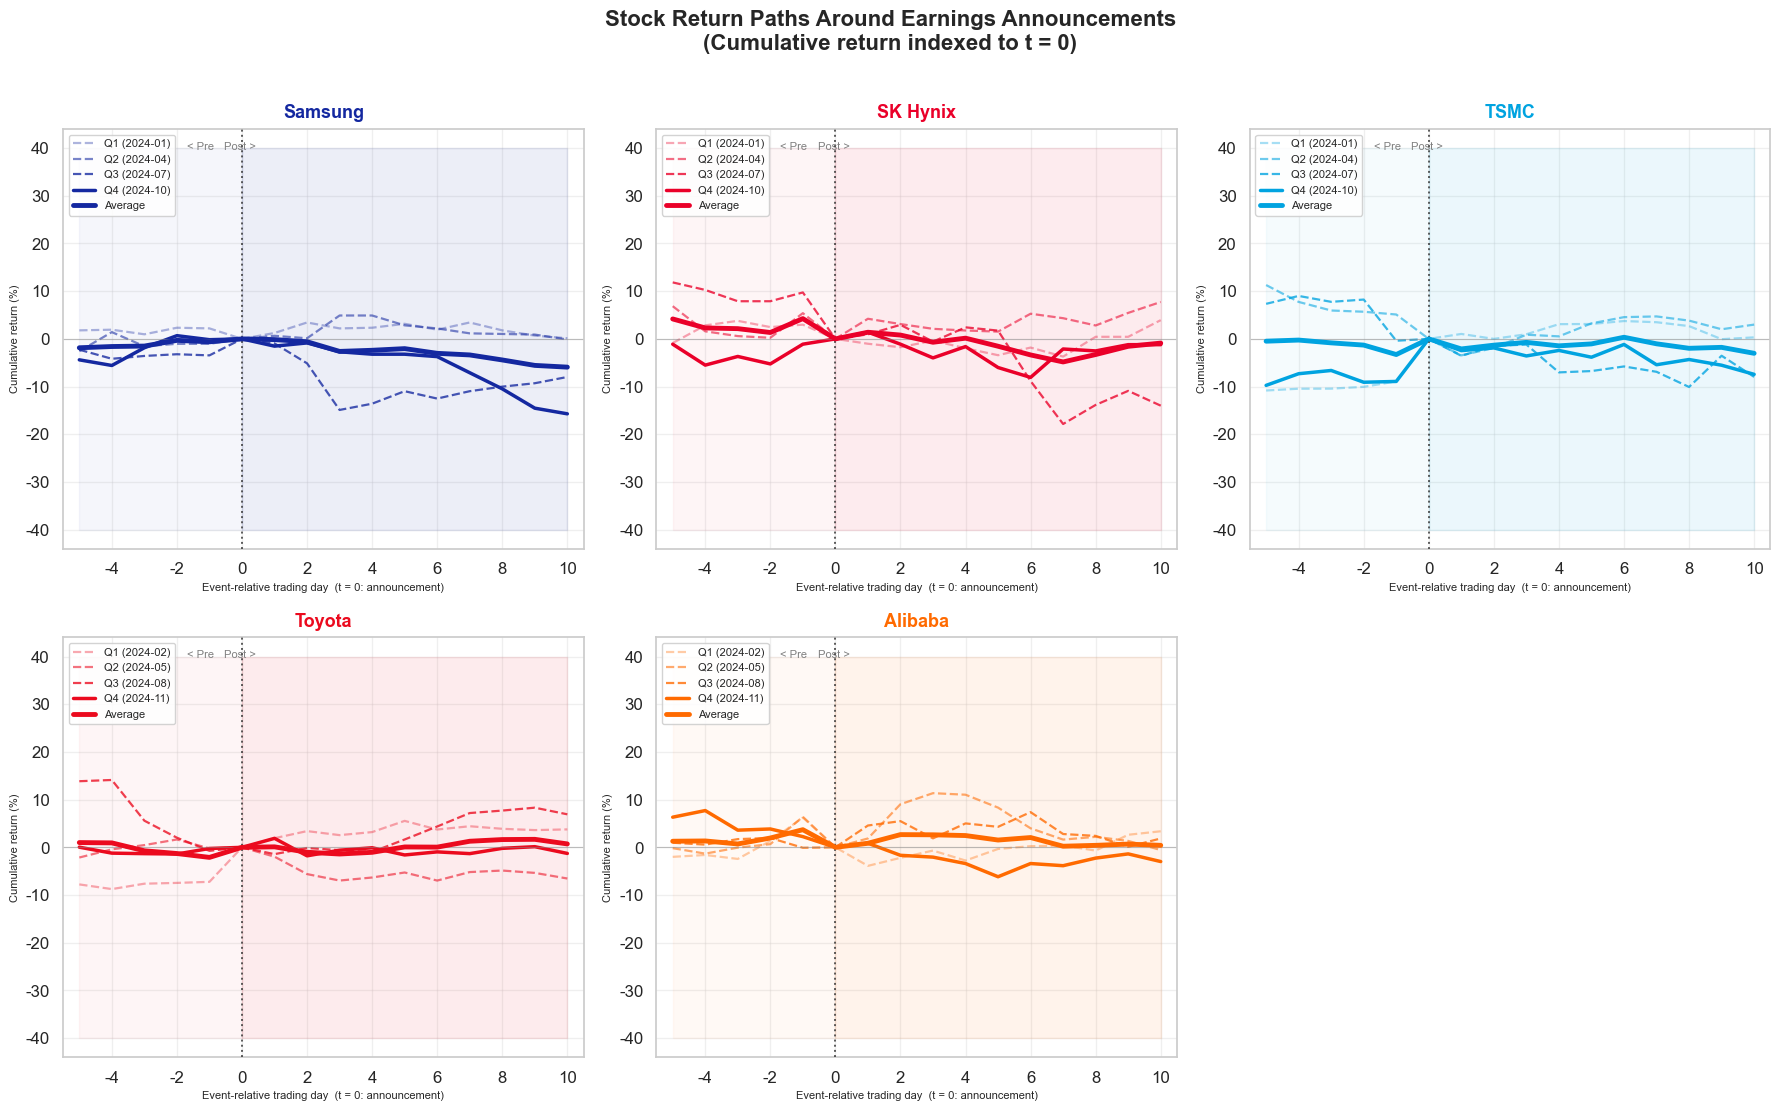

Saved: 01_individual_paths.png


In [6]:
def plot_individual(name: str, windows: list, info: dict, ax: plt.Axes) -> None:
    """Plot quarterly cumulative return paths for a single ticker."""
    color      = info['color']
    alpha_vals = np.linspace(0.35, 1.0, len(windows))

    for i, w in enumerate(windows):
        quarter_label = f"Q{i + 1} ({w['event_date'].values[0][:7]})"
        is_latest     = (i == len(windows) - 1)
        ax.plot(
            w['t'], w['cum_ret'],
            color=color,
            alpha=alpha_vals[i],
            linewidth=2.5 if is_latest else 1.6,
            linestyle='-'  if is_latest else '--',
            label=quarter_label,
        )

    # Average path across quarters
    if len(windows) > 1:
        avg = pd.concat([w.set_index('t')['cum_ret'] for w in windows], axis=1).mean(axis=1)
        ax.plot(avg.index, avg.values,
                color=color, linewidth=3.5, linestyle='-',
                label='Average', zorder=5)

    # Reference lines and shading
    ax.axvline(0,  color='#333333', linewidth=1.4, linestyle=':', alpha=0.8, zorder=4)
    ax.axhline(0,  color='#888888', linewidth=0.8, alpha=0.5)
    ax.fill_betweenx([-40, 40], -PRE_DAYS, 0,         alpha=0.04, color=color)
    ax.fill_betweenx([-40, 40],  0,         POST_DAYS, alpha=0.08, color=color)

    ax.set_title(name, fontsize=13, fontweight='bold', color=color, pad=8)
    ax.set_xlabel('Event-relative trading day  (t = 0: announcement)', fontsize=8)
    ax.set_ylabel('Cumulative return (%)', fontsize=8)
    ax.set_xlim(-PRE_DAYS - 0.5, POST_DAYS + 0.5)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax.legend(fontsize=8, loc='upper left', framealpha=0.85)
    ax.grid(True, alpha=0.3)
    ax.text(0.29, 0.97, '< Pre',  transform=ax.transAxes,
            fontsize=8, color='gray', va='top', ha='right')
    ax.text(0.31, 0.97, 'Post >', transform=ax.transAxes,
            fontsize=8, color='gray', va='top', ha='left')


fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()

for idx, (name, windows) in enumerate(all_results.items()):
    if windows:
        plot_individual(name, windows, STOCKS[name], axes_flat[idx])
    else:
        axes_flat[idx].text(0.5, 0.5, f'{name}\nNo data available',
                            ha='center', va='center',
                            transform=axes_flat[idx].transAxes, fontsize=11)

for ax in axes_flat[len(all_results):]:
    ax.set_visible(False)

fig.suptitle(
    'Stock Return Paths Around Earnings Announcements\n'
    '(Cumulative return indexed to t = 0)',
    fontsize=16, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('01_individual_paths.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_individual_paths.png')

## 5. Visualization — Cross-Ticker Average Path Overlay

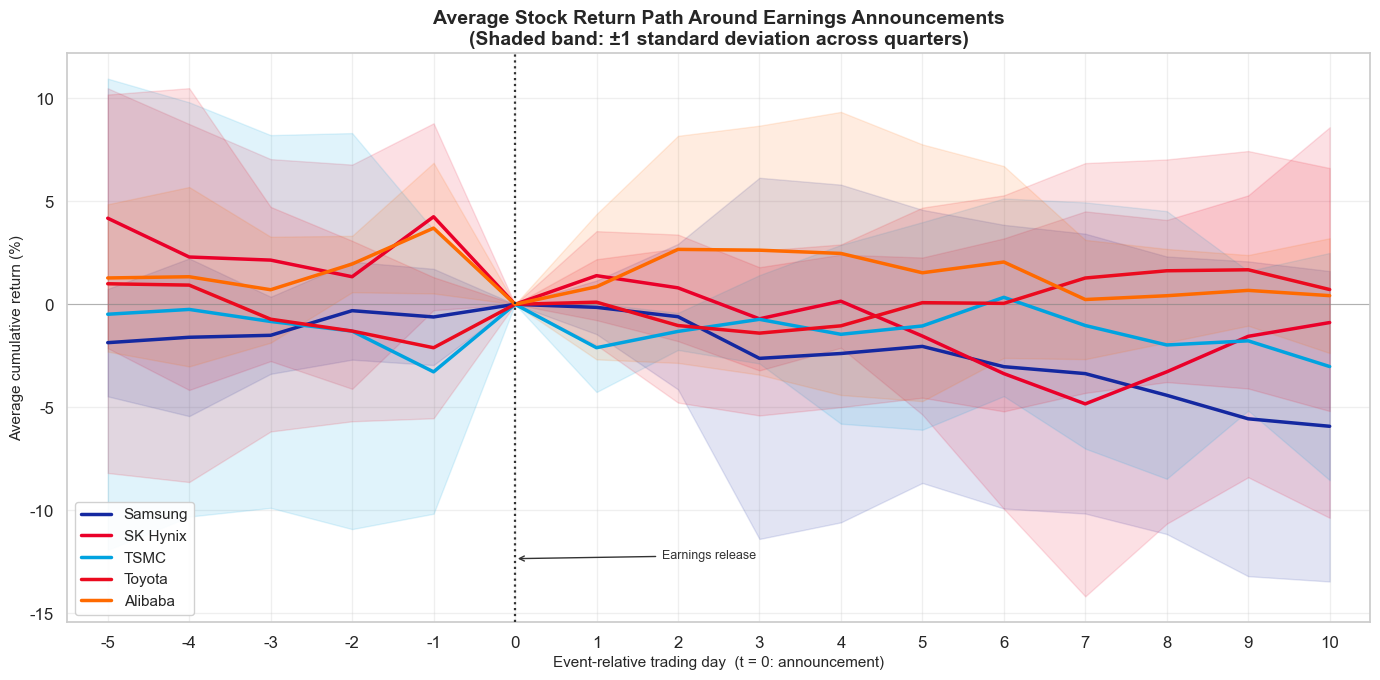

Saved: 02_comparison_overlay.png


In [7]:
fig, ax = plt.subplots(figsize=(14, 7))

for name, windows in all_results.items():
    if not windows:
        continue

    avg   = pd.concat([w.set_index('t')['cum_ret'] for w in windows], axis=1).mean(axis=1)
    std   = pd.concat([w.set_index('t')['cum_ret'] for w in windows], axis=1).std(axis=1)
    color = STOCKS[name]['color']

    ax.plot(avg.index, avg.values,
            color=color, linewidth=2.5, label=name, zorder=4)
    ax.fill_between(avg.index, avg - std, avg + std,
                    alpha=0.12, color=color)

ax.axvline(0, color='#333', linewidth=1.6, linestyle=':', zorder=5)
ax.axhline(0, color='#888', linewidth=0.8, alpha=0.6)
ax.set_xlim(-PRE_DAYS - 0.5, POST_DAYS + 0.5)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.set_xlabel('Event-relative trading day  (t = 0: announcement)', fontsize=11)
ax.set_ylabel('Average cumulative return (%)', fontsize=11)
ax.set_title(
    'Average Stock Return Path Around Earnings Announcements\n'
    '(Shaded band: ±1 standard deviation across quarters)',
    fontsize=14, fontweight='bold'
)
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)

ymin, _ = ax.get_ylim()
ax.annotate(
    'Earnings release',
    xy=(0, ymin * 0.8), xytext=(1.8, ymin * 0.8),
    arrowprops=dict(arrowstyle='->', color='#333'),
    fontsize=9, color='#333',
)

plt.tight_layout()
plt.savefig('02_comparison_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_comparison_overlay.png')

## 6. Heatmap — Post-Announcement Cumulative Returns

In [8]:
# Build summary table
records = []
for name, windows in all_results.items():
    for w in windows:
        wt  = w.set_index('t')
        rec = {
            'Ticker'        : name,
            'Earnings Date' : w['event_date'].values[0],
            't=0 Return'    : round(wt.loc[0,  'daily_ret'], 2),
            't=+1'          : round(wt.loc[1,  'daily_ret'], 2) if  1 in wt.index else np.nan,
            't=+2'          : round(wt.loc[2,  'daily_ret'], 2) if  2 in wt.index else np.nan,
            't=+3'          : round(wt.loc[3,  'daily_ret'], 2) if  3 in wt.index else np.nan,
            't=+5'          : round(wt.loc[5,  'daily_ret'], 2) if  5 in wt.index else np.nan,
            't=+10 Cum.'    : round(wt.loc[10, 'cum_ret'],   2) if 10 in wt.index else np.nan,
        }
        records.append(rec)

df_summary = pd.DataFrame(records)
ret_cols   = [c for c in df_summary.columns if c not in ('Ticker', 'Earnings Date')]

print('Post-Announcement Return Summary Table')
display(
    df_summary.style
    .format({c: '{:.2f}%' for c in ret_cols})
    .background_gradient(cmap='RdYlGn', subset=ret_cols, vmin=-5, vmax=5)
)

Post-Announcement Return Summary Table


,Ticker,Earnings Date,t=0 Return,t=+1,t=+2,t=+3,t=+5,t=+10 Cum.
0,Samsung,2024-01-31,-2.15%,1.24%,2.17%,-1.20%,0.81%,0.14%
1,Samsung,2024-04-30,1.04%,0.65%,-0.51%,4.77%,-1.97%,-0.13%
2,Samsung,2024-07-31,3.58%,-0.95%,-4.21%,-10.30%,3.03%,-7.99%
3,Samsung,2024-10-31,0.17%,-1.52%,0.69%,-1.87%,0.00%,-15.71%
4,SK Hynix,2024-01-25,-2.90%,-1.02%,-0.74%,1.41%,-1.48%,3.93%
5,SK Hynix,2024-04-25,-5.12%,4.22%,-1.07%,-0.97%,-0.23%,7.74%
6,SK Hynix,2024-07-25,-8.87%,0.95%,1.98%,-3.43%,-0.67%,-14.00%
7,SK Hynix,2024-10-24,1.12%,1.41%,-2.49%,-2.91%,-4.46%,-1.21%
8,TSMC,2024-01-18,9.79%,1.04%,-1.02%,0.97%,0.03%,0.32%
9,TSMC,2024-04-18,-4.86%,-3.46%,1.61%,2.84%,2.71%,2.99%


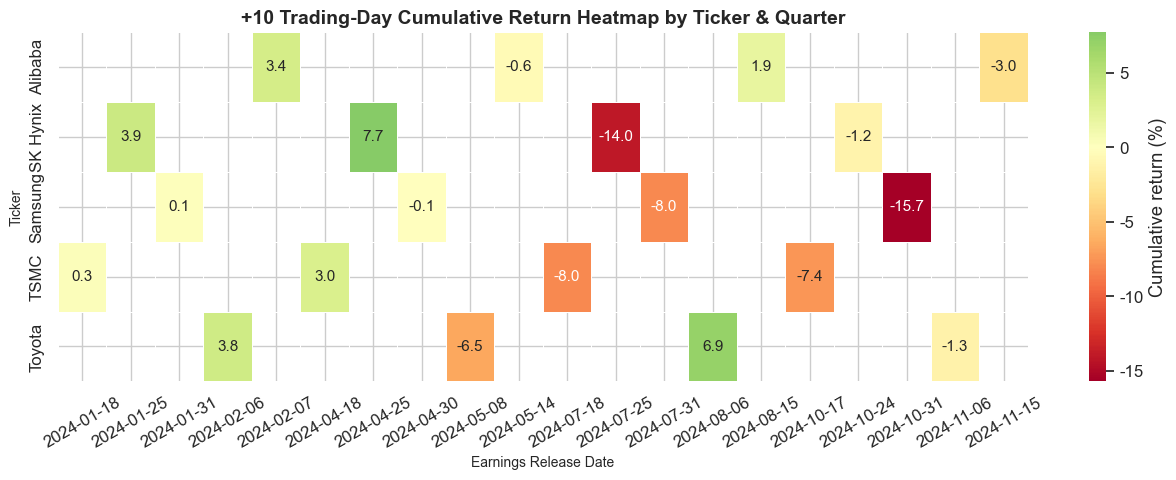

Saved: 03_heatmap_post10.png


In [9]:
# Pivot for heatmap: Ticker x Earnings Date, values = t+10 cumulative return
heatmap_data = df_summary.pivot_table(
    index='Ticker', columns='Earnings Date', values='t=+10 Cum.'
).sort_index(axis=1)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1f', center=0,
    cmap='RdYlGn', linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Cumulative return (%)'},
    annot_kws={'fontsize': 11},
    ax=ax,
)
ax.set_title('+10 Trading-Day Cumulative Return Heatmap by Ticker & Quarter',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Earnings Release Date', fontsize=10)
ax.set_ylabel('Ticker', fontsize=10)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('03_heatmap_post10.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_heatmap_post10.png')

## 7. Distribution of Announcement-Day Reactions & Post-Release Daily Returns

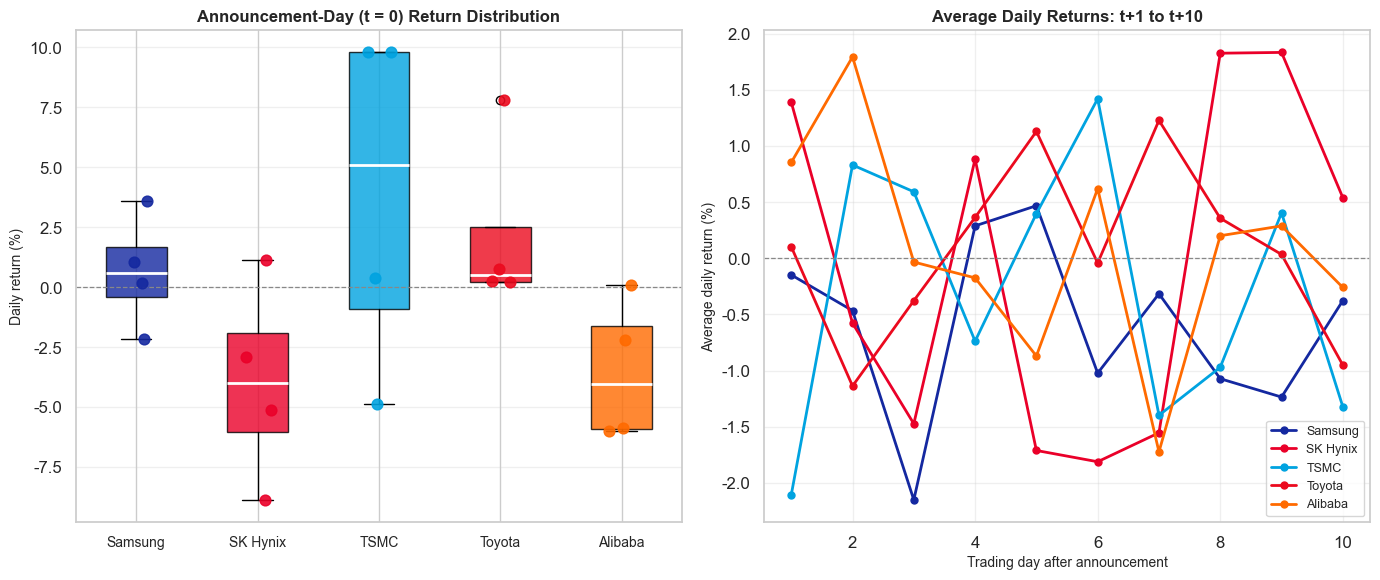

Saved: 04_reaction_distribution.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: boxplot of t=0 daily returns ───────────────────────────────────────
box_data, box_labels, box_colors = [], [], []
for name, windows in all_results.items():
    if not windows:
        continue
    vals = [w.set_index('t').loc[0, 'daily_ret'] for w in windows]
    box_data.append(vals)
    box_labels.append(name)
    box_colors.append(STOCKS[name]['color'])

bp = axes[0].boxplot(
    box_data,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    widths=0.5,
)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

# Jittered scatter overlay
rng = np.random.default_rng(42)
for i, (vals, color) in enumerate(zip(box_data, box_colors)):
    jitter = rng.uniform(-0.12, 0.12, len(vals))
    axes[0].scatter([i + 1 + j for j in jitter], vals,
                    color=color, alpha=0.9, s=60, zorder=5)

axes[0].axhline(0, color='#888', linewidth=0.9, linestyle='--')
axes[0].set_xticks(range(1, len(box_labels) + 1))
axes[0].set_xticklabels(box_labels, fontsize=10)
axes[0].set_ylabel('Daily return (%)', fontsize=10)
axes[0].set_title('Announcement-Day (t = 0) Return Distribution', fontsize=12, fontweight='bold')
axes[0].grid(True, axis='y', alpha=0.3)

# ── Right: average daily returns for t+1 to t+10 ─────────────────────────────
for name, windows in all_results.items():
    if not windows:
        continue
    post_matrix = [
        w.set_index('t').loc[1:POST_DAYS, 'daily_ret'].values
        for w in windows
    ]
    avg_post = np.nanmean(post_matrix, axis=0)
    axes[1].plot(
        range(1, POST_DAYS + 1), avg_post,
        marker='o', markersize=5,
        color=STOCKS[name]['color'],
        label=name, linewidth=2,
    )

axes[1].axhline(0, color='#888', linewidth=0.9, linestyle='--')
axes[1].set_xlabel('Trading day after announcement', fontsize=10)
axes[1].set_ylabel('Average daily return (%)', fontsize=10)
axes[1].set_title('Average Daily Returns: t+1 to t+10', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_reaction_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_reaction_distribution.png')

## 8. Reaction Strength Ranking

In [11]:
# ── Build ranking metrics ─────────────────────────────────────────────────────
ranking_rows = []

for name, windows in all_results.items():
    if not windows:
        continue

    day0_rets  = [w.set_index('t').loc[0,  'daily_ret'] for w in windows]
    post5_cum  = [w.set_index('t').loc[5,  'cum_ret']   for w in windows]
    post10_cum = [w.set_index('t').loc[10, 'cum_ret']   for w in windows]
    abs_day0   = [abs(r) for r in day0_rets]

    ranking_rows.append({
        'Ticker'                   : name,
        'Quarters'                 : len(windows),
        'Avg Day-0 Return (%)'     : round(np.mean(day0_rets),  2),
        'Avg |Day-0| Return (%)'   : round(np.mean(abs_day0),   2),
        'Avg Cum. Return +5d (%)'  : round(np.mean(post5_cum),  2),
        'Avg Cum. Return +10d (%)' : round(np.mean(post10_cum), 2),
        'Max +10d Return (%)'      : round(max(post10_cum),     2),
        'Min +10d Return (%)'      : round(min(post10_cum),     2),
        'Volatility Std +10d (%)'  : round(
            np.std(post10_cum, ddof=1) if len(post10_cum) > 1 else 0, 2
        ),
    })

df_rank = pd.DataFrame(ranking_rows)

# Composite score: weighted sum of abs day-0 reaction, abs +10d cumulative, and volatility
df_rank['Composite Score'] = (
    df_rank['Avg |Day-0| Return (%)']       * 0.4
    + df_rank['Avg Cum. Return +10d (%)'].abs() * 0.4
    + df_rank['Volatility Std +10d (%)']    * 0.2
).round(3)

df_rank = df_rank.sort_values('Composite Score', ascending=False).reset_index(drop=True)
df_rank.index      = df_rank.index + 1
df_rank.index.name = 'Rank'

pct_cols = [c for c in df_rank.columns if '%' in c]

print('Earnings Reaction Strength Ranking')
print('Composite Score = |Day-0| x 0.4  +  |+10d Cum.| x 0.4  +  Volatility x 0.2')
print('=' * 80)
display(
    df_rank.style
    .format({c: '{:.2f}%' for c in pct_cols})
    .format({'Composite Score': '{:.3f}'})
    .background_gradient(subset=['Composite Score'], cmap='YlOrRd')
    .bar(subset=['Avg Day-0 Return (%)'],     color=['#ff9999', '#99cc99'], align='zero')
    .bar(subset=['Avg Cum. Return +10d (%)'], color=['#ffb3b3', '#b3d9b3'], align='zero')
)

Earnings Reaction Strength Ranking
Composite Score = |Day-0| x 0.4  +  |+10d Cum.| x 0.4  +  Volatility x 0.2


,Ticker,Quarters,Avg Day-0 Return (%),Avg |Day-0| Return (%),Avg Cum. Return +5d (%),Avg Cum. Return +10d (%),Max +10d Return (%),Min +10d Return (%),Volatility Std +10d (%),Composite Score
Rank,,,,,,,,,,
1,TSMC,4,3.780000,6.210000,-1.050000,-3.020000,2.990000,-7.970000,5.510000,4.794
2,Samsung,4,0.660000,1.740000,-2.040000,-5.920000,0.140000,-15.710000,7.540000,4.572
3,SK Hynix,4,-3.940000,4.500000,-1.540000,-0.890000,7.740000,-14.000000,9.480000,4.052
4,Toyota,4,2.250000,2.250000,0.080000,0.720000,6.920000,-6.540000,5.900000,2.368
5,Alibaba,4,-3.500000,3.540000,1.530000,0.420000,3.370000,-2.980000,2.790000,2.142


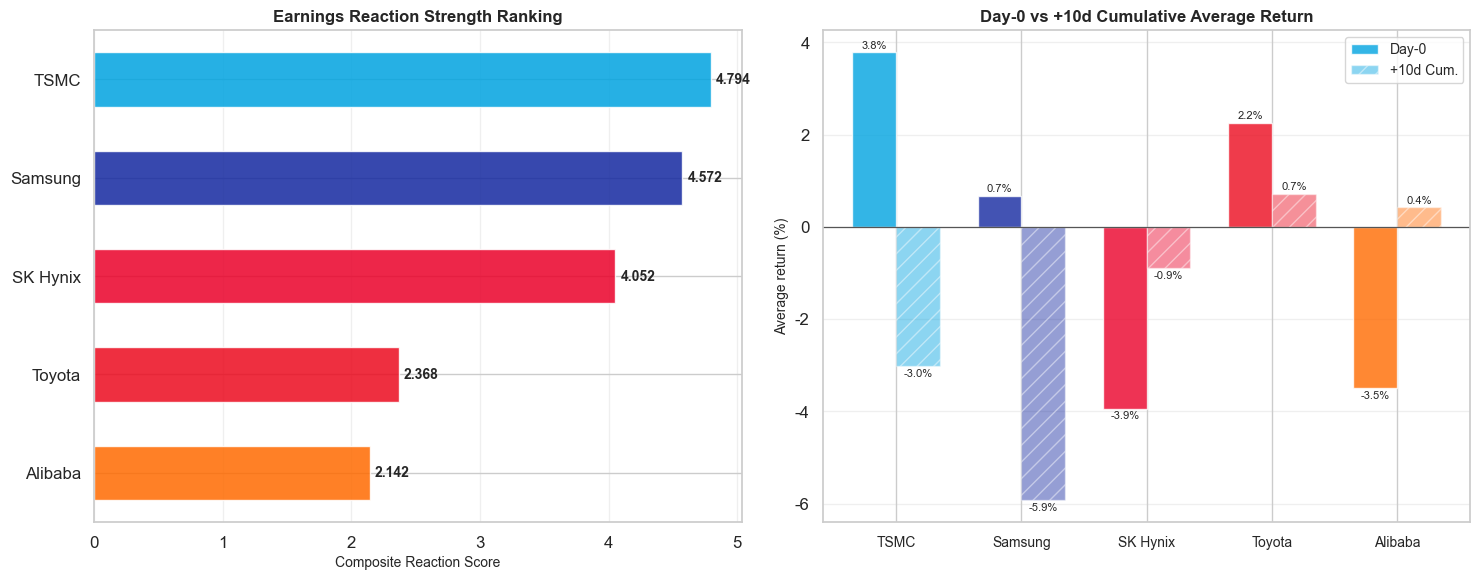

Saved: 05_ranking.png


In [12]:
# ── Ranking visualization ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ordered_names  = df_rank['Ticker'].tolist()
ordered_colors = [STOCKS[n]['color'] for n in ordered_names]
scores         = df_rank['Composite Score'].tolist()

# Left: composite score horizontal bar chart
bars = axes[0].barh(
    ordered_names[::-1], scores[::-1],
    color=ordered_colors[::-1], alpha=0.85, height=0.55
)
for bar, score in zip(bars, scores[::-1]):
    axes[0].text(
        bar.get_width() + 0.04,
        bar.get_y() + bar.get_height() / 2,
        f'{score:.3f}', va='center', fontsize=10, fontweight='bold'
    )
axes[0].set_xlabel('Composite Reaction Score', fontsize=10)
axes[0].set_title('Earnings Reaction Strength Ranking', fontsize=12, fontweight='bold')
axes[0].grid(True, axis='x', alpha=0.3)

# Right: grouped bar — day-0 vs +10d cumulative
x = np.arange(len(ordered_names))
w = 0.35
day0_vals   = df_rank['Avg Day-0 Return (%)'].tolist()
post10_vals = df_rank['Avg Cum. Return +10d (%)'].tolist()

b1 = axes[1].bar(x - w / 2, day0_vals,   w,
                 color=ordered_colors, alpha=0.80, label='Day-0')
b2 = axes[1].bar(x + w / 2, post10_vals, w,
                 color=ordered_colors, alpha=0.45, hatch='//', label='+10d Cum.')
axes[1].axhline(0, color='#555', linewidth=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(ordered_names, fontsize=10)
axes[1].set_ylabel('Average return (%)', fontsize=10)
axes[1].set_title('Day-0 vs +10d Cumulative Average Return', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, axis='y', alpha=0.3)

# Value labels on bars
for bar in list(b1) + list(b2):
    h      = bar.get_height()
    va     = 'bottom' if h >= 0 else 'top'
    offset = 0.05 if h >= 0 else -0.05
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        h + offset,
        f'{h:.1f}%', ha='center', va=va, fontsize=8
    )

plt.tight_layout()
plt.savefig('05_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_ranking.png')

## 9. Statistical Significance — Welch's t-Test

Tests whether post-announcement daily returns differ significantly from pre-announcement returns  
using a two-sample Welch t-test (unequal variances assumed).

In [13]:
stat_rows = []

for name, windows in all_results.items():
    if not windows:
        continue

    pre_pool, post_pool = [], []
    for w in windows:
        wt = w.set_index('t')
        pre_pool.extend(wt.loc[-PRE_DAYS:-1, 'daily_ret'].dropna().tolist())
        post_pool.extend(wt.loc[1:POST_DAYS,  'daily_ret'].dropna().tolist())

    if len(pre_pool) < 2 or len(post_pool) < 2:
        continue

    t_stat, p_val = stats.ttest_ind(post_pool, pre_pool, equal_var=False)
    significance  = ('***' if p_val < 0.01
                     else '**'  if p_val < 0.05
                     else '*'   if p_val < 0.10
                     else 'n.s.')

    stat_rows.append({
        'Ticker'             : name,
        'Pre-Ann. Mean (%)'  : round(np.mean(pre_pool),  3),
        'Post-Ann. Mean (%)' : round(np.mean(post_pool), 3),
        't-Statistic'        : round(t_stat, 4),
        'p-Value'            : round(p_val,  4),
        'Significance'       : significance,
    })

df_stat = pd.DataFrame(stat_rows)

print('Welch t-Test Results  (Post-Announcement vs Pre-Announcement Daily Returns)')
print('Significance levels:  * p<0.10   ** p<0.05   *** p<0.01   n.s. not significant')
print('=' * 70)
display(
    df_stat.style
    .format({
        'Pre-Ann. Mean (%)'  : '{:.3f}%',
        'Post-Ann. Mean (%)' : '{:.3f}%',
        't-Statistic'        : '{:.4f}',
        'p-Value'            : '{:.4f}',
    })
)

Welch t-Test Results  (Post-Announcement vs Pre-Announcement Daily Returns)
Significance levels:  * p<0.10   ** p<0.05   *** p<0.01   n.s. not significant


,Ticker,Pre-Ann. Mean (%),Post-Ann. Mean (%),t-Statistic,p-Value,Significance
0,Samsung,0.335%,-0.603%,-1.5216,0.1371,n.s.
1,SK Hynix,0.072%,-0.065%,-0.1525,0.8797,n.s.
2,TSMC,-0.604%,-0.289%,0.4314,0.6696,n.s.
3,Toyota,-0.689%,0.071%,1.1970,0.2448,n.s.
4,Alibaba,0.623%,0.069%,-0.7504,0.4593,n.s.


## 10. Summary

In [14]:
print('=' * 65)
print('  Earnings Reaction Analysis — Final Summary')
print('=' * 65)

top = df_rank.iloc[0]
print(f"\nStrongest reaction: {top['Ticker']}")
print(f"  Avg day-0 return      : {top['Avg Day-0 Return (%)']:+.2f}%")
print(f"  Avg +10d cum. return  : {top['Avg Cum. Return +10d (%)']:+.2f}%")
print(f"  Composite score       : {top['Composite Score']:.3f}")

print('\nFull ranking:')
for i, row in df_rank.iterrows():
    print(
        f"  #{i}  {row['Ticker']:<12}"
        f"  Day-0: {row['Avg Day-0 Return (%)']:+.2f}%"
        f"  +10d: {row['Avg Cum. Return +10d (%)']:+.2f}%"
        f"  Score: {row['Composite Score']:.3f}"
    )

print('\nGenerated charts:')
charts = [
    ('01_individual_paths.png',      'Per-ticker quarterly return paths'),
    ('02_comparison_overlay.png',    'Cross-ticker average path overlay  (+-1 SD band)'),
    ('03_heatmap_post10.png',        '+10d cumulative return heatmap'),
    ('04_reaction_distribution.png', 'Day-0 boxplot & post-release daily returns'),
    ('05_ranking.png',               'Composite reaction strength ranking'),
]
for fname, desc in charts:
    print(f"  {fname:<38} {desc}")
print('=' * 65)

  Earnings Reaction Analysis — Final Summary

Strongest reaction: TSMC
  Avg day-0 return      : +3.78%
  Avg +10d cum. return  : -3.02%
  Composite score       : 4.794

Full ranking:
  #1  TSMC          Day-0: +3.78%  +10d: -3.02%  Score: 4.794
  #2  Samsung       Day-0: +0.66%  +10d: -5.92%  Score: 4.572
  #3  SK Hynix      Day-0: -3.94%  +10d: -0.89%  Score: 4.052
  #4  Toyota        Day-0: +2.25%  +10d: +0.72%  Score: 2.368
  #5  Alibaba       Day-0: -3.50%  +10d: +0.42%  Score: 2.142

Generated charts:
  01_individual_paths.png                Per-ticker quarterly return paths
  02_comparison_overlay.png              Cross-ticker average path overlay  (+-1 SD band)
  03_heatmap_post10.png                  +10d cumulative return heatmap
  04_reaction_distribution.png           Day-0 boxplot & post-release daily returns
  05_ranking.png                         Composite reaction strength ranking


## 결과 해석

### 반응 강도 vs 지속성의 불일치
Composite Score 기준 1위는 TSMC(+3.78%)였으나,
발표 후 10일 누적 수익률은 -3.02%로 하락 전환했다.
삼성전자(-5.92%), SK하이닉스(-0.89%)도 마찬가지였다.
반면 발표 당일 반응이 약했던 도요타와 알리바바는
10일 후에도 상승을 유지했다.

→ 실적 발표 당일의 강한 반응이 지속적 상승을 보장하지 않는다.

## 11. Post-Announcement Cumulative Return: Day 0 → Day 20
### Base price: Day −1 closing price (one trading day before announcement)

All cumulative returns are indexed to the **Day −1 close** so that  
the Day-0 bar already captures the full announcement-day move.

In [19]:
# ── Parameters ────────────────────────────────────────────────────────────────
POST_DAYS_EXT : int = 20
# Total rows needed: 1 (Day -1 anchor) + 1 (Day 0) + POST_DAYS_EXT


def get_post_window_d1base(
    ticker_sym : str,
    event_date : str,
    post       : int = POST_DAYS_EXT,
    buffer     : int = 40,
) -> pd.DataFrame | None:
    """
    Fetch price data from Day -1 through Day +post relative to the earnings date.
    Cumulative return is anchored to the Day -1 closing price.

    Parameters
    ----------
    ticker_sym : yfinance-compatible ticker string
    event_date : announcement date ('YYYY-MM-DD')
    post       : number of trading days after announcement to include
    buffer     : extra calendar days fetched to guarantee enough trading days

    Returns
    -------
    DataFrame with columns:
        day        : integer day index  (-1 = day before announcement,
                                          0 = announcement day, 1..post = after)
        close      : adjusted closing price
        cum_ret    : cumulative return from Day -1 close (%)
        event_date : announcement date string
    Returns None if insufficient data.
    """
    ed    = pd.Timestamp(event_date)
    start = ed - pd.offsets.BDay(5 + buffer)   # generous pre-buffer to find Day -1
    end   = ed + pd.offsets.BDay(post + buffer)

    try:
        raw = yf.download(ticker_sym, start=start, end=end,
                          auto_adjust=True, progress=False)
    except Exception as exc:
        print(f'  [ERROR] {ticker_sym}: download failed — {exc}')
        return None

    if raw.empty:
        return None

    # Flatten MultiIndex if present
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    df = raw[['Close']].copy()
    df.index = pd.DatetimeIndex(df.index).tz_localize(None)

    # Locate Day 0: nearest trading day >= event_date
    trading_days = df.index.tolist()
    future_days  = [d for d in trading_days if d >= ed]
    if not future_days:
        return None

    day0_pos = df.index.get_loc(future_days[0])

    # Day -1 must exist
    if day0_pos < 1:
        return None

    # Slice from Day -1 through Day +post
    start_pos = day0_pos - 1
    end_pos   = day0_pos + post + 1

    if end_pos > len(df):
        return None

    window = df.iloc[start_pos:end_pos].copy()
    if len(window) < post + 2:          # need Day-1 + Day0 + post days
        return None

    # Day -1 close is the base price
    base_price = window['Close'].iloc[0]

    # Assign day index: -1, 0, 1, 2, ..., post
    window['day']        = range(-1, post + 1)
    window['cum_ret']    = (window['Close'] / base_price - 1) * 100
    window['event_date'] = event_date
    window.rename(columns={'Close': 'close'}, inplace=True)

    return window.reset_index(drop=True)


# ── Collect data ──────────────────────────────────────────────────────────────
ext_results: dict = {}

print(f'Fetching Day-1 to Day+{POST_DAYS_EXT} price data (base = Day -1 close)...\n')
for name, info in STOCKS.items():
    windows = []
    for edate in info['earnings']:
        w = get_post_window_d1base(info['ticker'], edate)
        if w is not None:
            windows.append(w)
    ext_results[name] = windows
    print(f'  {name:<12}  {len(windows)}/{len(info["earnings"])} quarters collected')

print('\nData collection complete.')

Fetching Day-1 to Day+20 price data (base = Day -1 close)...

  Samsung       4/4 quarters collected
  SK Hynix      4/4 quarters collected
  TSMC          4/4 quarters collected
  Toyota        4/4 quarters collected
  Alibaba       4/4 quarters collected

Data collection complete.


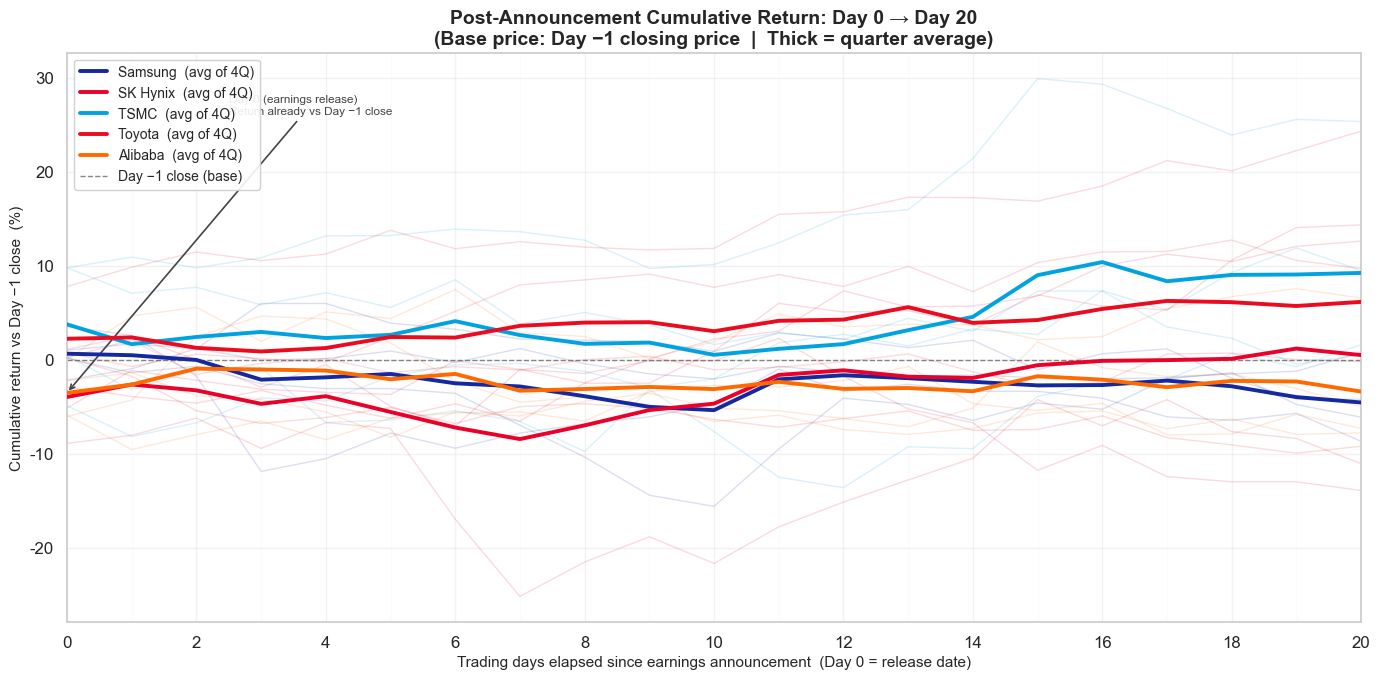

Saved: 06_post_cumret_d1base_overlay.png


In [20]:
# ── Overlay chart: all tickers, Day 0 → Day +20 (base = Day -1 close) ─────────
# x-axis starts at 0 (announcement day); Day -1 is shown only as the zero anchor.

fig, ax = plt.subplots(figsize=(14, 7))

for name, windows in ext_results.items():
    if not windows:
        continue

    color = STOCKS[name]['color']

    # Filter to Day 0 onward for plotting
    post_windows = [w[w['day'] >= 0] for w in windows]

    # Individual quarter traces (faint background)
    for w in post_windows:
        ax.plot(
            w['day'], w['cum_ret'],
            color=color, alpha=0.15, linewidth=1.0, linestyle='-',
        )

    # Average path
    avg = (
        pd.concat([w.set_index('day')['cum_ret'] for w in post_windows], axis=1)
        .mean(axis=1)
    )
    ax.plot(
        avg.index, avg.values,
        color=color, linewidth=2.8,
        label=f'{name}  (avg of {len(windows)}Q)',
        zorder=5,
    )

# Zero line represents Day -1 close level
ax.axhline(0, color='#555', linewidth=1.0, linestyle='--', alpha=0.7,
           label='Day −1 close (base)')

ax.set_xlim(0, POST_DAYS_EXT)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))
ax.set_xlabel(
    'Trading days elapsed since earnings announcement  (Day 0 = release date)',
    fontsize=11,
)
ax.set_ylabel('Cumulative return vs Day −1 close  (%)', fontsize=11)
ax.set_title(
    'Post-Announcement Cumulative Return: Day 0 → Day 20\n'
    '(Base price: Day −1 closing price  |  Thick = quarter average)',
    fontsize=14, fontweight='bold',
)
ax.legend(fontsize=10, framealpha=0.9, loc='upper left')
ax.grid(True, which='major', alpha=0.25)
ax.grid(True, which='minor', alpha=0.08)

# Annotation
ymin, ymax = ax.get_ylim()
ax.annotate(
    'Day 0 (earnings release)\nReturn already vs Day −1 close',
    xy=(0, avg.iloc[0] if len(avg) else 0),
    xytext=(2.5, ymax * 0.80),
    arrowprops=dict(arrowstyle='->', color='#444', lw=1.2),
    fontsize=8.5, color='#444',
)

plt.tight_layout()
plt.savefig('06_post_cumret_d1base_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06_post_cumret_d1base_overlay.png')

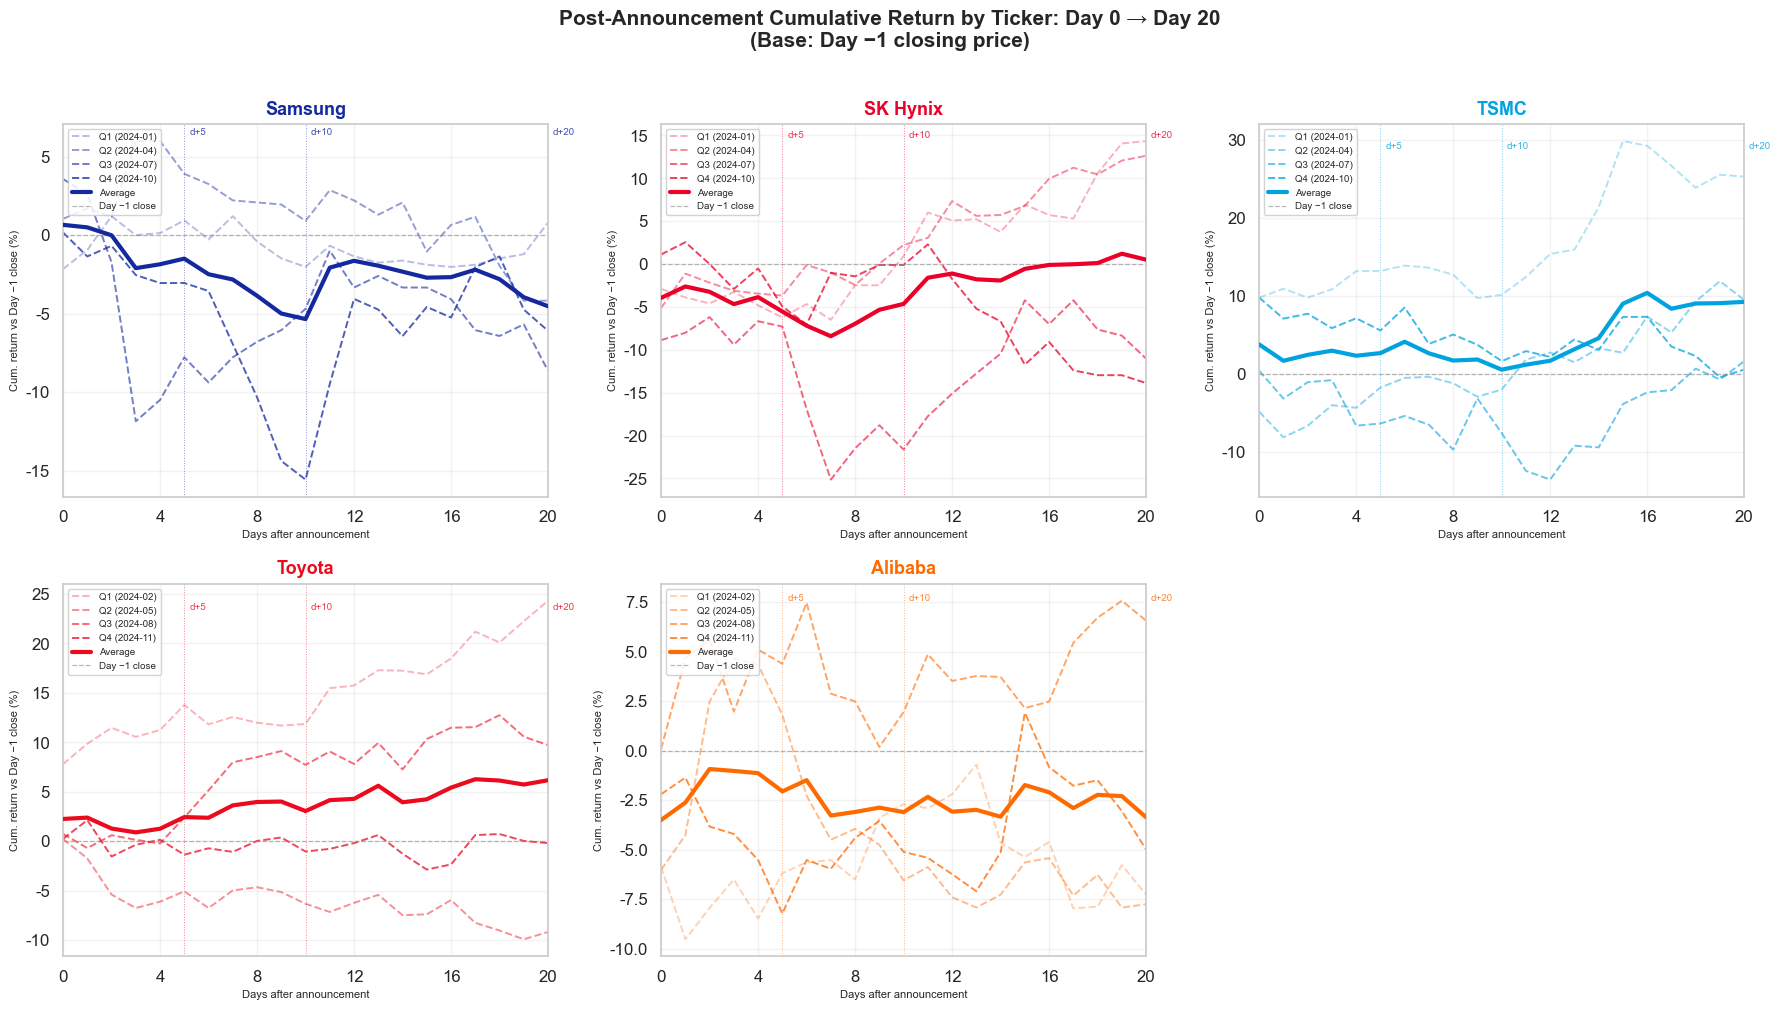

Saved: 07_post_cumret_d1base_small_multiples.png


In [21]:
# ── Small multiples: one subplot per ticker ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=False)
axes_flat = axes.flatten()

for idx, (name, windows) in enumerate(ext_results.items()):
    ax    = axes_flat[idx]
    color = STOCKS[name]['color']

    if not windows:
        ax.text(0.5, 0.5, f'{name}\nNo data available',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
        continue

    alpha_vals   = np.linspace(0.30, 0.75, len(windows))
    post_windows = [w[w['day'] >= 0] for w in windows]

    for i, w in enumerate(post_windows):
        ax.plot(
            w['day'], w['cum_ret'],
            color=color, alpha=alpha_vals[i],
            linewidth=1.4, linestyle='--',
            label=f"Q{i + 1} ({windows[i]['event_date'].values[0][:7]})",
        )

    # Average path
    avg = (
        pd.concat([w.set_index('day')['cum_ret'] for w in post_windows], axis=1)
        .mean(axis=1)
    )
    ax.plot(avg.index, avg.values,
            color=color, linewidth=3.0, linestyle='-',
            label='Average', zorder=5)

    # Milestone verticals
    _, ymax_sub = ax.get_ylim()
    for milestone in [5, 10, 20]:
        if milestone in avg.index:
            ax.axvline(milestone, color=color, linewidth=0.7,
                       linestyle=':', alpha=0.5)
            ax.text(milestone + 0.2, ax.get_ylim()[1] * 0.90,
                    f'd+{milestone}', fontsize=7, color=color, alpha=0.8)

    ax.axhline(0, color='#888', linewidth=0.9, linestyle='--', alpha=0.6,
               label='Day −1 close')
    ax.set_xlim(0, POST_DAYS_EXT)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(4))
    ax.set_xlabel('Days after announcement', fontsize=8)
    ax.set_ylabel('Cum. return vs Day −1 close (%)', fontsize=8)
    ax.set_title(name, fontsize=13, fontweight='bold', color=color, pad=7)
    ax.legend(fontsize=7, loc='upper left', framealpha=0.85)
    ax.grid(True, alpha=0.25)

for ax in axes_flat[len(ext_results):]:
    ax.set_visible(False)

fig.suptitle(
    'Post-Announcement Cumulative Return by Ticker: Day 0 → Day 20\n'
    '(Base: Day −1 closing price)',
    fontsize=15, fontweight='bold', y=1.01,
)
plt.tight_layout()
plt.savefig('07_post_cumret_d1base_small_multiples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 07_post_cumret_d1base_small_multiples.png')

In [22]:
# ── Milestone table: avg cumulative return at Day 0, +5, +10, +15, +20 ────────
# All values are vs Day -1 close.
milestone_days = [0, 5, 10, 15, 20]
milestone_rows = []

for name, windows in ext_results.items():
    if not windows:
        continue

    row = {'Ticker': name}
    for d in milestone_days:
        vals = []
        for w in windows:
            wday = w.set_index('day')
            if d in wday.index:
                vals.append(wday.loc[d, 'cum_ret'])
        col_label    = f'Day +{d} (%)' if d > 0 else 'Day 0 (%)'
        row[col_label] = round(np.mean(vals), 2) if vals else np.nan

    milestone_rows.append(row)

df_milestone = pd.DataFrame(milestone_rows).set_index('Ticker')
ret_cols     = df_milestone.columns.tolist()

print('Average Cumulative Return at Each Milestone Day')
print('(Base price: Day −1 closing price)')
print('=' * 60)
display(
    df_milestone.style
    .format({c: '{:+.2f}%' for c in ret_cols})
    .background_gradient(cmap='RdYlGn', axis=None, vmin=-8, vmax=8)
    .set_properties(**{'font-size': '11pt', 'text-align': 'center'})
)

Average Cumulative Return at Each Milestone Day
(Base price: Day −1 closing price)


,Day 0 (%),Day +5 (%),Day +10 (%),Day +15 (%),Day +20 (%)
Ticker,,,,,
Samsung,+0.66%,-1.49%,-5.34%,-2.71%,-4.52%
SK Hynix,-3.94%,-5.53%,-4.65%,-0.56%,+0.52%
TSMC,+3.78%,+2.66%,+0.54%,+9.01%,+9.25%
Toyota,+2.25%,+2.44%,+3.05%,+4.24%,+6.17%
Alibaba,-3.50%,-2.05%,-3.10%,-1.73%,-3.36%


## 추가 분석 배경 및 의의

### 왜 추가했나
10번 분석에서 Day+0을 기준점으로 설정했을 때,
발표 당일의 주가 반응이 측정에서 누락되는 문제를 발견했다.
실적 발표는 통상 장 마감 후 이루어지므로
발표 전날(Day-1) 종가가 더 정확한 기준점이다.
기준점 변경 후 종목별 수익률이 유의미하게 달라졌다.

### 종목별 패턴 (Day-1 기준, Day+20까지)

**① 꾸준한 우상향 — 도요타(+6.17%), TSMC(+9.25%)**
도요타는 발표 당일부터 20일까지 완만하게 지속 상승(+6.27%).
TSMC는 발표 당일  +3.78% 반응 후 10일까지 횡보했으나, 15~20일 구간에서 +9.25%로 급반등.
전형적인 PEAD(Post-Earnings Announcement Drift) 패턴

**② 단기 하락 후 회복 — SK하이닉스**
발표 당일 -3.94% 하락했으나 20일 후 +0.52%로 회복.
하락의 원인은 보유 데이터만으로 특정하긴 어려우나, EPS 컨센서스 대비 실제 실적 차이 데이터 확보 시 추가 해석이 가능하다.

**③ 지속 하락 — 삼성전자(-4.52%), 알리바바(-3.36%)**
20일 내내 회복하지 못함.
실적 발표 자체가 주가에 부정적으로 작용한 사례.

### 1번 프로젝트와의 연결
가격 기반 팩터(모멘텀 + PBR) 종합 평가에서 최하위를 기록한
TSMC가 실적 발표 후 Day+20 기준 +9.25%로 최고 수익률을 달성했다.

이는 가격 기반 팩터만으로는 실적 발표 이후의 주가 상승을
사전에 포착하기 어려움을 시사한다.
종목 선별의 정확도를 높이기 위해서는
Earnings Surprise 팩터를 추가한 다중 팩터 모델 확장이 필요하다.

**다중 팩터 모델 확장시 예측력이 떨어지는 문제가 발생될 수 있다. 
**통계적 보정 방법을 고려할 수 있다.(다중공선성, IC(information coefficient), 교차검증, 알파감쇠)
***factor수에 따른 다양한 모델이 있다.
****Fama-French 3factor, Carhart 4factor, Fama-French 5factor, 블룸버그, BARRA 등
*****블룸버그, 바라 등과 같은 팩터수가 10-20개인 모델이 실무에서 이용될 수 있다.


## 한계 및 개선 방향

### 한계
1. **실제 EPS 서프라이즈 미반영**
   애널리스트 예측치 대비 실제 실적 차이를 직접 계산하지 못하고
   주가 반응으로 대체했음. 실제 컨센서스 데이터 사용 시 정확도 향상 가능.

2. **샘플 부족**
   5개 종목, 단일 분기만 분석하여 통계적 신뢰도 낮음.
   패턴의 일관성 검증을 위해 최소 8~12분기 데이터 필요.

3. **시장 환경 미반영**
   분석 기간 중 전체 시장 등락이 개별 종목 반응에
   영향을 줬을 수 있음. 시장 대비 초과수익률(Alpha)
   측정으로 개선 가능.

### 향후 개선 방향
- Bloomberg Terminal의 실제 EPS 컨센서스 데이터 연동
- 분석 대상 종목 및 분기 수 확장
- 1번 프로젝트 Multi-factor 모델에
  Earnings Surprise 팩터 추가하여 3-factor 통합 모델로 발전 예정